# [LAB 07] 추론통계 - 12. 교차분석 

## #01. 준비작업

### 1. 라이브러리 참조 


In [1]:
from jussam import load_data
from helpers import * 

import numpy as np
from pandas import DataFrame, crosstab

# 교차분석에 필요한 기능 참조 
from scipy.stats import chisquare, chi2_contingency, fisher_exact, chi2

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기 

In [2]:
origin = load_data("movie_view")
origin.head()

📚 OTT 서비스 업체 무비뷰의 회원 500명을 대상으로 조사된 가상의 데이터 셋

    field         description
--  ------------  --------------------------------------
 0  회원ID        회원 식별자 (인덱스)
 1  가입요일      가입한 요일(월~일)
 2  성별          남성 / 여성
 3  프리미엄전환  프리미엄 요금제 전환 여부(전환/미전환)
 4  지역          서울 / 부산 / 대구
 5  선호장르      액션 / 로맨스 / 다큐 / 예능
 6  베타그룹      신규 UI 베타테스트 그룹(A/B)
 7  베타만족      베타테스트 만족 여부(만족/불만족)



,가입요일,성별,지역,선호장르,프리미엄전환,베타그룹,베타만족
회원ID,,,,,,,
M0001,토,여성,부산,다큐,미전환,NaN,NaN
M0002,토,남성,서울,예능,미전환,NaN,NaN
M0003,금,여성,대구,다큐,미전환,NaN,NaN
M0004,토,남성,서울,로맨스,미전환,NaN,NaN
M0005,일,남성,대구,다큐,미전환,NaN,NaN


### 3. 데이터 확인 

In [3]:
origin.info()

<class 'pandas.DataFrame'>
Index: 500 entries, M0001 to M0500
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   가입요일    500 non-null    str  
 1   성별      500 non-null    str  
 2   지역      500 non-null    str  
 3   선호장르    500 non-null    str  
 4   프리미엄전환  500 non-null    str  
 5   베타그룹    30 non-null     str  
 6   베타만족    30 non-null     str  
dtypes: str(7)
memory usage: 48.4 KB


## #02. 적합도 검정 

### 1. 관측 빈도와 기대 빈도 계산

In [4]:
# 요일 순서를 고정하기 위한 기준 리스트 (월~일)     
days = ['월', '화', '수', '목', '금', '토', '일']

# 요일별 가입자 수를 세고, days 순서대로 재정렬(관측빈도)
observed = origin['가입요일'].value_counts().reindex(days)

# 균등가정 기대빈도 : 전체 인원을 7로 나눠 모든 요일에 동일하게 채움 
expected = np.full(len(days), observed.sum() / len(days))

print('요일별 가입자 수 (관측빈도):') 
print(observed)
print('균등 가정 기대빈도(요일당):', round(expected[0], 1)) 
print(expected.round(1))


요일별 가입자 수 (관측빈도):
가입요일
월     58
화     48
수     44
목     66
금     87
토     96
일    101
Name: count, dtype: int64
균등 가정 기대빈도(요일당): 71.4
[71.4 71.4 71.4 71.4 71.4 71.4 71.4]


### 2. 가정 확인

In [5]:
n_under_5 = int((expected<5).sum()) # 기대빈도가 5미만인 칸의 개수
pct_ok = (expected>=5).mean() # 기대빈도가 5이상인 칸의 비율
min_exp = expected.min() # 기대빈도 중 최소값 계산 

print(f'천체 칸 수 : {expected.size}')
print(f'기대빈도 5미만 칸 수 : {n_under_5}')
print(f'기대빈도 5이상 칸 비율 : {pct_ok:0%}')
print(f'최소 기대빈도 : {min_exp:.1f}')

# 5 이상 비율 80% 이상 & 최소 기대빈도 1이상이면 가정 충족 
if pct_ok >= 0.8 and min_exp >=1: 
    print('\n 가정충족 -> 적합도 카이제곱 검정 사용 가능')
else : 
    print('\n 가정 위한 -> 범주 병합 등 대안 검토')  

천체 칸 수 : 7
기대빈도 5미만 칸 수 : 0
기대빈도 5이상 칸 비율 : 100.000000%
최소 기대빈도 : 71.4

 가정충족 -> 적합도 카이제곱 검정 사용 가능


### 3. 적합도 검정 수행 

In [6]:
# 적합도 카이제곱 검정 : 관측빈도와 기대빈도 비교 -> 통계량과 p-value 반환
chi2, p = chisquare(f_obs=observed.values, f_exp=expected)
print("statistics:", chi2, "p-value:", p)

statistics: 45.244 p-value: 4.185729660522544e-08


### 4. 강도 확인

In [7]:
n_total = observed.sum() # 전체 표본 수 (관측빈도 합계) 계산 
cohen_w = np.sqrt(chi2 / n_total) # 효과크기 계산 
print(f"Cohen's w : {cohen_w:.3f}")

Cohen's w : 0.301


### 5. 결과 시각화를 위한 데이터 재배치 

In [8]:
plot_df = DataFrame({
    # 요일 라벨을 관측/기대용으로 2번 반복 
    '요일': list(observed.index)*2,
    # 앞쪽은 관측, 뒤쪽은 기대로 구분
    '구분': ['관측']*len(days) +['기대']*len(days), 
    # 관측빈도 + 기대빈도를 하나의 값 컬럼으로 결합 
    '가입자수'  :   list(observed.values) + list(expected)
})

plot_df

,요일,구분,가입자수
0,월,관측,58.000
1,화,관측,48.000
2,수,관측,44.000
3,목,관측,66.000
4,금,관측,87.000
5,토,관측,96.000
6,일,관측,101.000
7,월,기대,71.429
8,화,기대,71.429
9,수,기대,71.429


### 6. 결과 시각화 

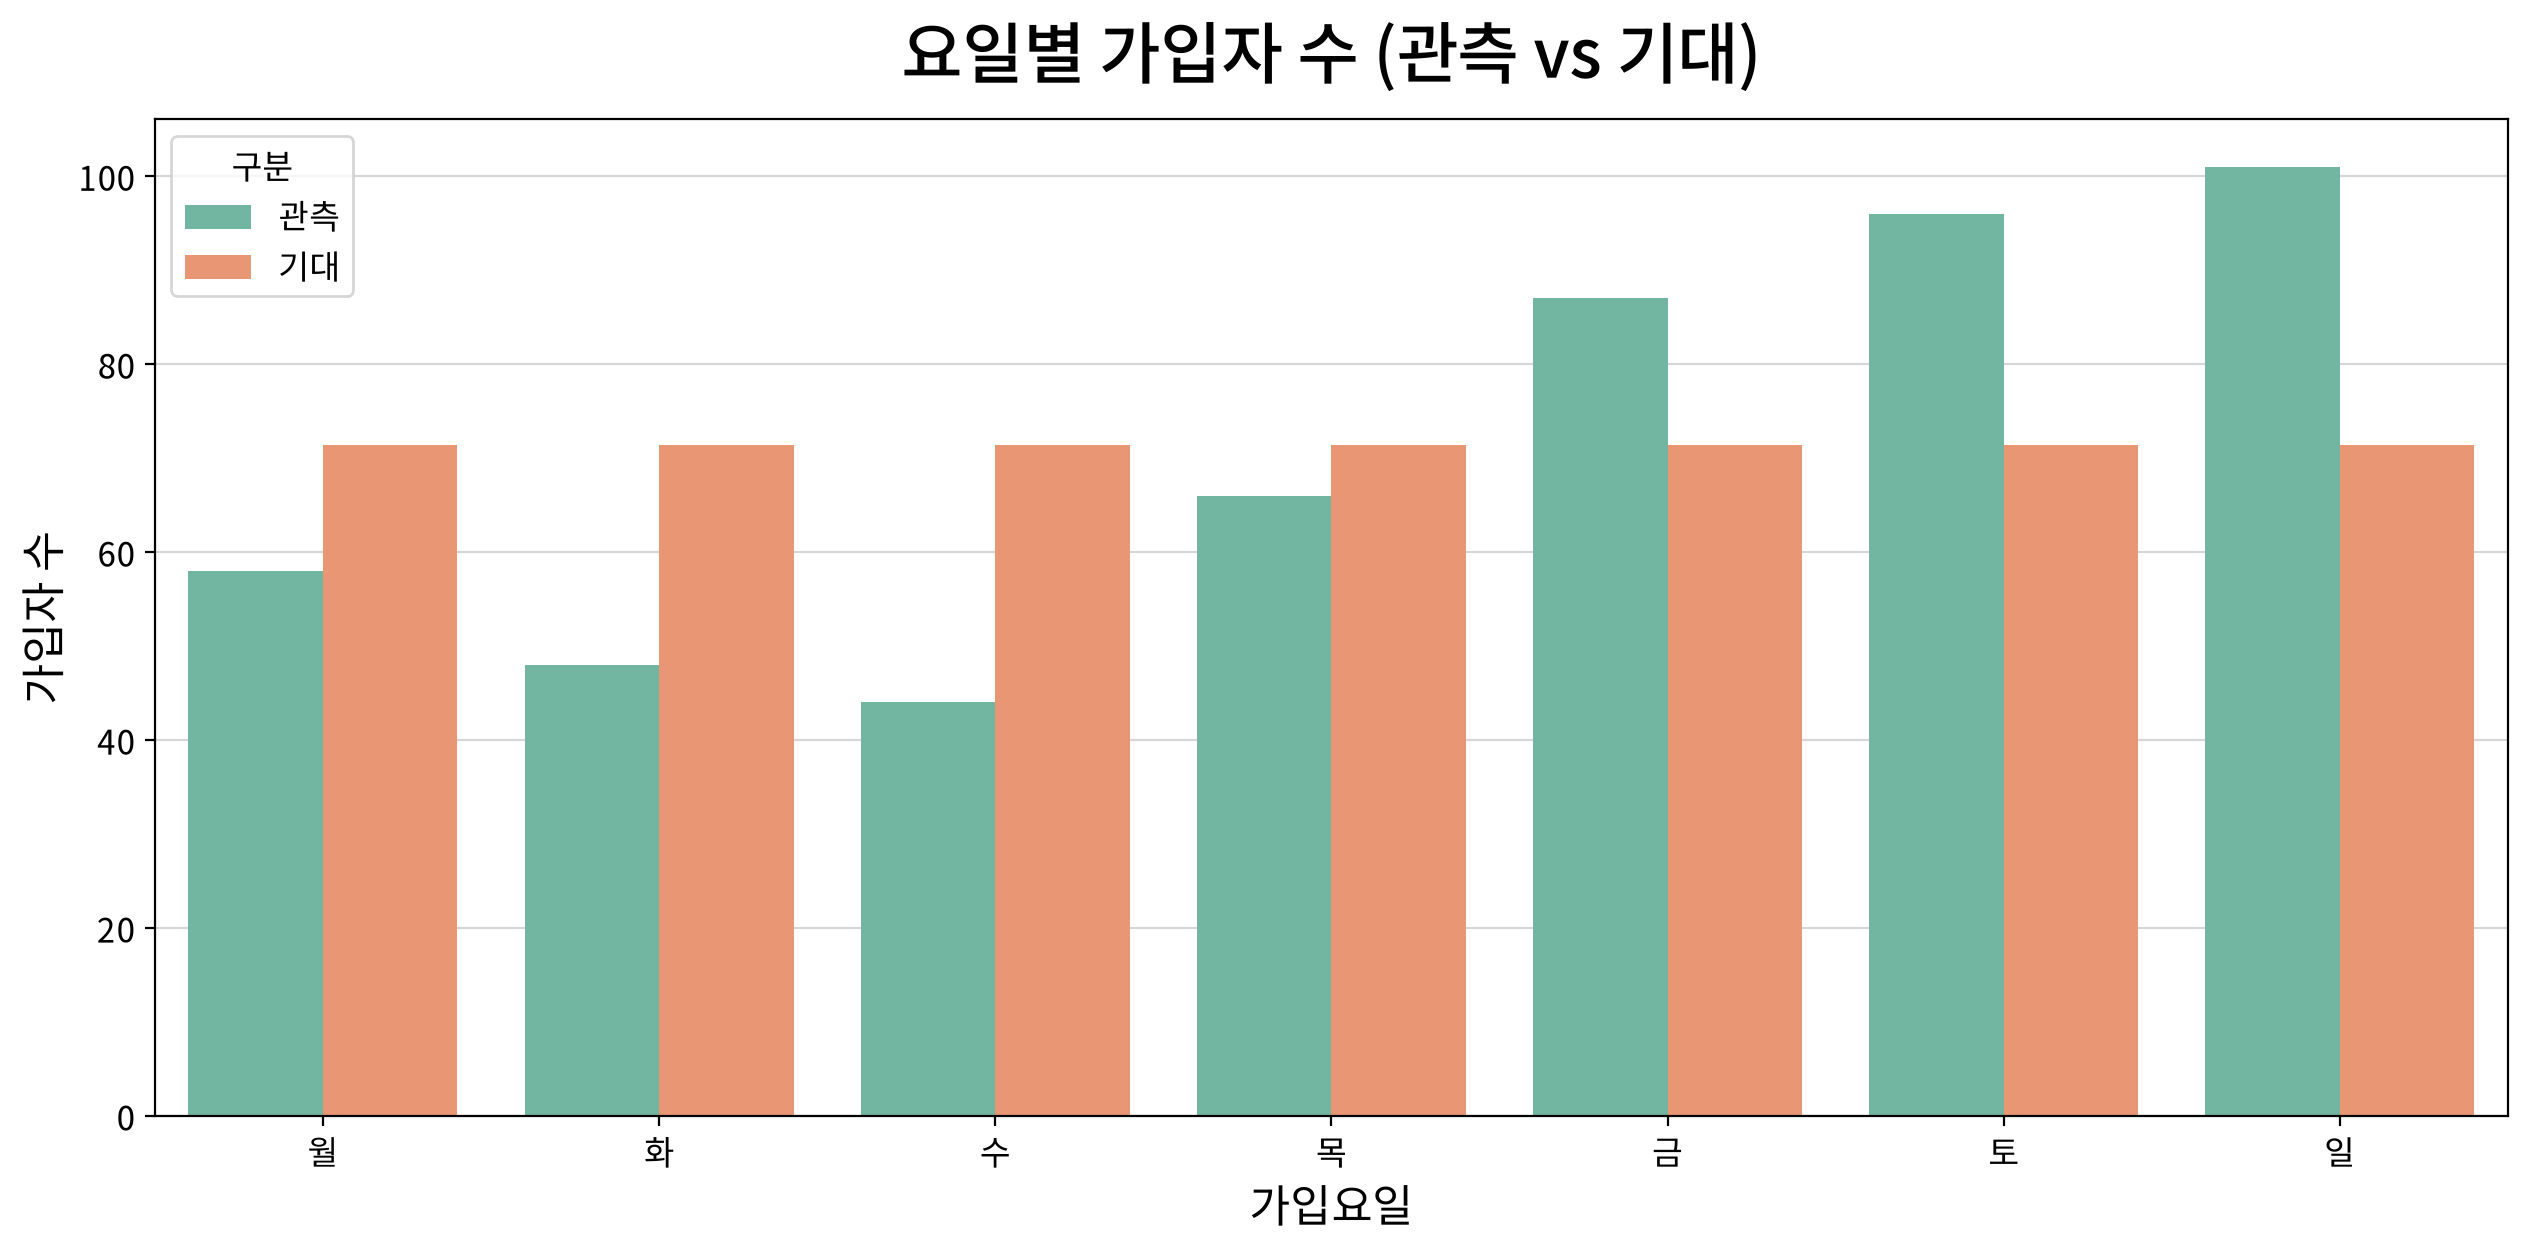

In [9]:
# 요일별 관측 vs 기대빈도를 나란히 그리는 이중 막대 그래프 
my_plot.barplot(data=plot_df, x='요일', y='가입자수', 
                hue='구분', order=days, 
                palette='Set2', title='요일별 가입자 수 (관측 vs 기대)',
                xlabel='가입요일', ylabel='가입자 수')

## #03. 독립성 검정 

### 1. 대상 데이터 전처리

In [10]:
ct = crosstab(origin['성별'], origin['프리미엄전환'])
ct

프리미엄전환,미전환,전환
성별,,
남성,169,73
여성,115,143


### 2. 가정 확인 

In [11]:
chi2, p, dof, expected = chi2_contingency(ct)

# 기대빈도 확인 
cdf = DataFrame(expected, index=ct.index, columns=ct.columns)
display(cdf)

pct_ok = (expected>=5).mean()
print(f'\n 기대빈도 5미만 셀 수 : {int((expected<5).sum())}')
print(f'최소 기대빈도 : {expected.min():.1f}')
print('가정 충족 -> 카이제곱 검정' if (pct_ok >= 0.8 and expected.min() >=1) 
      else '가정 위반 -> 대안 검토')   

프리미엄전환,미전환,전환
성별,,
남성,137.456,104.544
여성,146.544,111.456



 기대빈도 5미만 셀 수 : 0
최소 기대빈도 : 104.5
가정 충족 -> 카이제곱 검정


### 3. 독립성 검정 확인 

In [12]:
chi2, p, dof, expected = chi2_contingency(ct)
print(f'\n카이제곱 통계량: {chi2:.4f}, p-value: {p:.3f}, 자유도: {dof}')


카이제곱 통계량: 31.4527, p-value: 0.000, 자유도: 1


### 4. 강도 확인 

In [13]:
n_total = ct.values.sum() 
min_dim = min(ct.shape) -1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
print(f"크라메르 V : {cramers_v:.3f}")

크라메르 V : 0.251


### 5. 시각화 

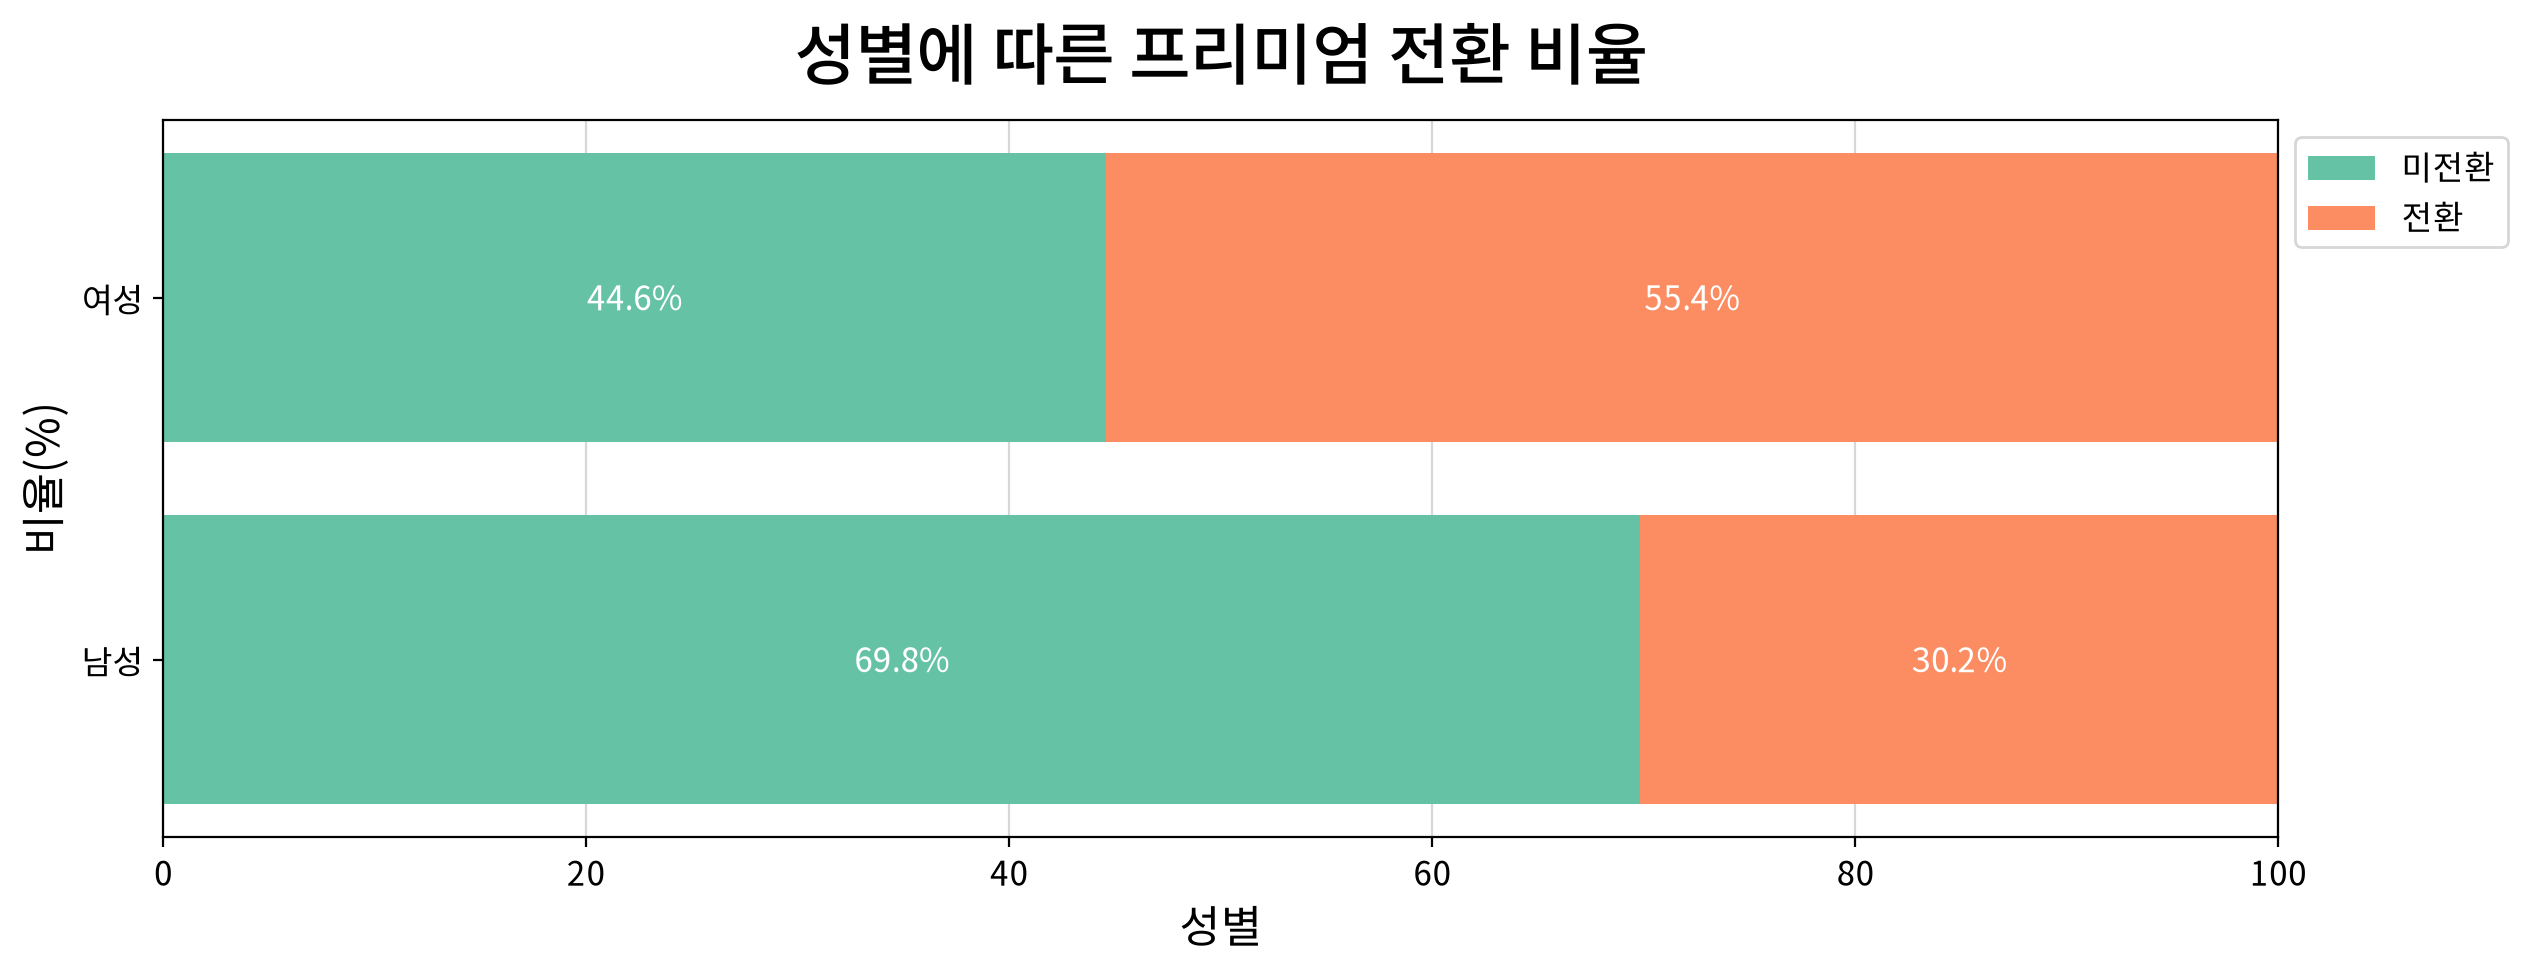

In [14]:
data = origin.copy()
data['원인'] = 1 

my_plot.stackplot(data=data, 
                  x='성별', y='원인', hue='프리미엄전환', orient='h', 
                  aggfunc='sum', ratio=True, palette='Set2',
                  title='성별에 따른 프리미엄 전환 비율',
                  xlabel='성별', ylabel='비율(%)', 
                  height=500)

## #04. 동질성 검정 

### 1. 대상 데이터 전처리 

In [15]:
ct2 = crosstab(origin['지역'], origin['선호장르'])
ct2

선호장르,다큐,로맨스,액션,예능
지역,,,,
대구,49,21,18,42
부산,30,74,31,35
서울,29,34,83,54


### 2. 가정 확인 

In [16]:
chi2, p, dof, expected = chi2_contingency(ct2)

cdf = DataFrame(expected, index=ct2.index, columns=ct2.columns)
display(cdf)

pct_ok = (expected >= 5).mean() 
print(f'\n기대빈도 5미만 셀 수 : {int((expected<5).sum())}')    
print(f'최소 기대빈도 : {expected.min():.1f}')
print('가정 충족 -> 카이제곱 검정' if (pct_ok >= 0.8 and expected.min() >=1) 
      else '가정 위반 -> 대안 검토')  

선호장르,다큐,로맨스,액션,예능
지역,,,,
대구,28.080,33.540,34.320,34.060
부산,36.720,43.860,44.880,44.540
서울,43.200,51.600,52.800,52.400



기대빈도 5미만 셀 수 : 0
최소 기대빈도 : 28.1
가정 충족 -> 카이제곱 검정


### 3. 동질성 검정 

In [17]:
chi2, p, dof, expected = chi2_contingency(ct2)
print(f'n\카이제곱 통계량: {chi2:.3f}, p-value: {p:.3f}, 자유도: {dof}')

n\카이제곱 통계량: 86.156, p-value: 0.000, 자유도: 6


### 4. 강도 확인

In [18]:
n_total = ct.sum().sum()
min_dim = min(ct2.shape) -1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
print(f'크라메르 V : {cramers_v:.3f}')

residuals = (ct2.values - expected) / np.sqrt(expected)
DataFrame(residuals, index=ct2.index, columns=ct2.columns)

크라메르 V : 0.294


선호장르,다큐,로맨스,액션,예능
지역,,,,
대구,3.948,-2.165,-2.786,1.360
부산,-1.109,4.551,-2.072,-1.429
서울,-2.160,-2.450,4.156,0.221


### 5. 시각화 

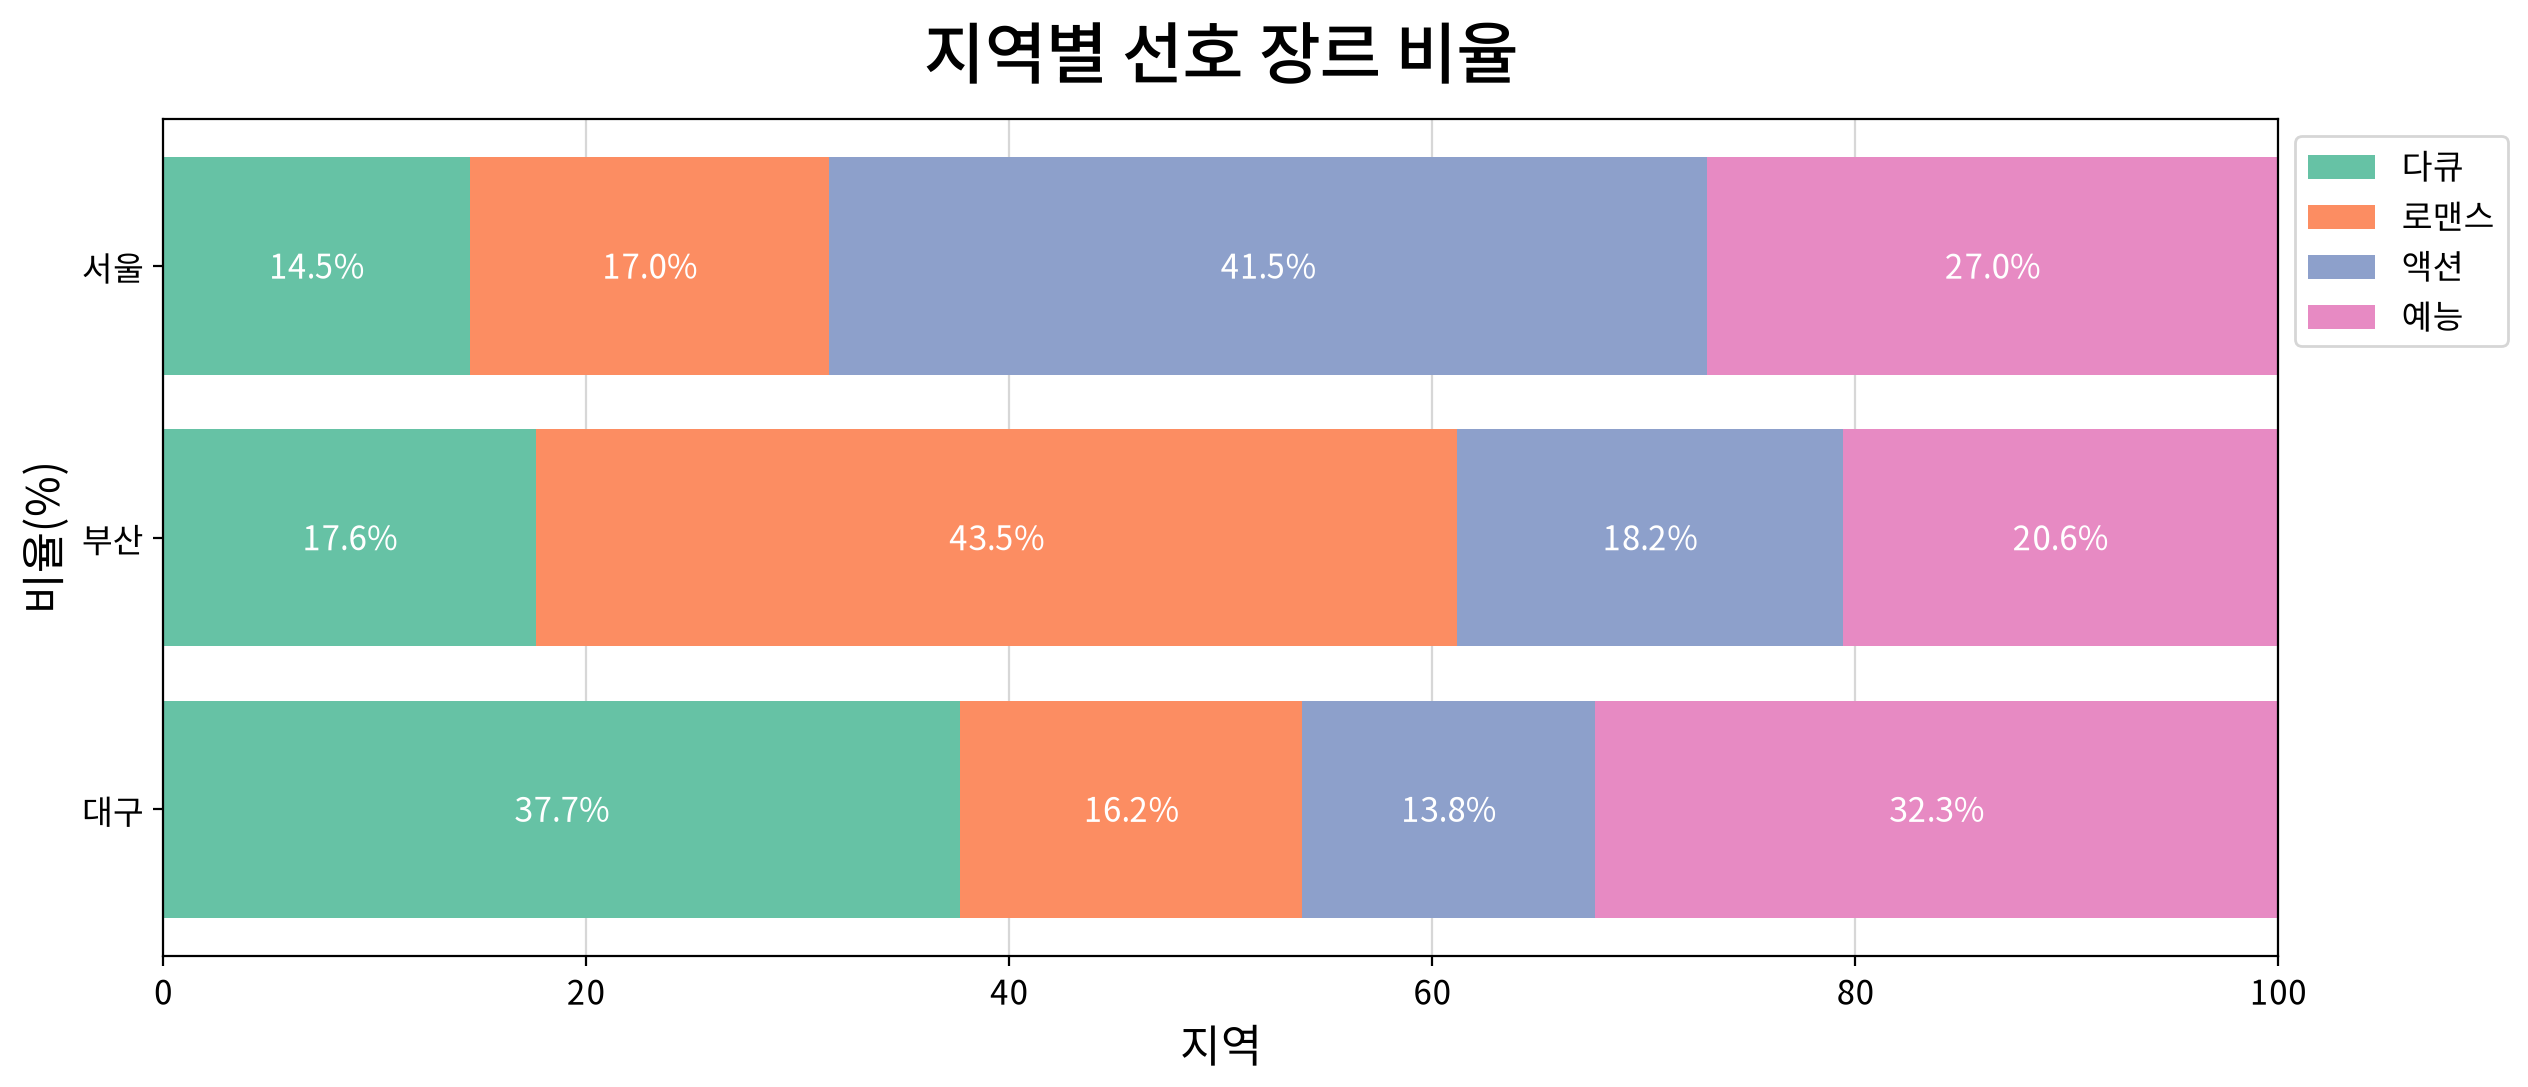

In [19]:
data = origin.copy()
data['인원'] = 1

my_plot.stackplot(data=data, x='지역', y='인원', hue='선호장르', orient='h', 
                  aggfunc='sum', ratio=True, palette='Set2',
                  title='지역별 선호 장르 비율', 
                  xlabel='지역', ylabel='비율(%)', height=560)

## #05. 가정에 위배된 경우( Fisher의 정확 검정 )

### 1. 대상 데이터 전처리 

In [20]:
# 데이터 정리 : 베타테스트 참여자만 추출
beta_df = origin.dropna(subset=['베타그룹', '베타만족']).copy()
print('베타테스트 참여자 수: ', len(beta_df))

# 교차표
ct3 = crosstab(beta_df['베타그룹'], beta_df['베타만족'])
ct3 = ct3[['만족', '불만족']].reindex(['A', 'B'])
ct3

베타테스트 참여자 수:  30


베타만족,만족,불만족
베타그룹,,
A,17,1
B,8,4


### 2. 가정확인

In [21]:
chi2, p, dof, expected = chi2_contingency(ct3)

print('-> 기대빈도')
display(DataFrame(expected, index=ct3.index, columns=ct3.columns))

n_under_5 = int((expected < 5).sum())
print(f'\n기대빈도 5 미만 셀 수: {n_under_5} / {expected.size}')
print(f'최소 기대빈도 : {expected.min():.1f}')

if (expected >=5).mean() >=0.8 and expected.min() >=1 :
    print('\n가정 충족')
else:
    print('\n가정 위반')

-> 기대빈도


베타만족,만족,불만족
베타그룹,,
A,15.000,3.000
B,10.000,2.000



기대빈도 5 미만 셀 수: 2 / 4
최소 기대빈도 : 2.0

가정 위반


### 3. 카이제곱 vs Fisher 검정 

In [22]:
# 예이츠 보정이 적용되지 않은 카이제곱 검정 ( 카이제곱 검정의 원래 형태 )
_, p_raw, _, _ = chi2_contingency(ct3, correction=False)
print(f'카이제곱(예이츠 보정 X) p-value : {p_raw:.4f}')

# 예이츠 보정이 적용된 카이제곱 검정 (scipy의 기본값)
_, p_yates, _, _ = chi2_contingency(ct3, correction=False)
print(f'카이제곱(예이츠 보정 0) p-value : {p_yates:.4f}')

# Fisher 정확검정 
odds, p_fisher = fisher_exact(ct3)
print(f'Fisher 정확검정 p-value : {p_fisher:.4f}')

카이제곱(예이츠 보정 X) p-value : 0.0455
카이제곱(예이츠 보정 0) p-value : 0.0455
Fisher 정확검정 p-value : 0.1282


### 4. 시각화 

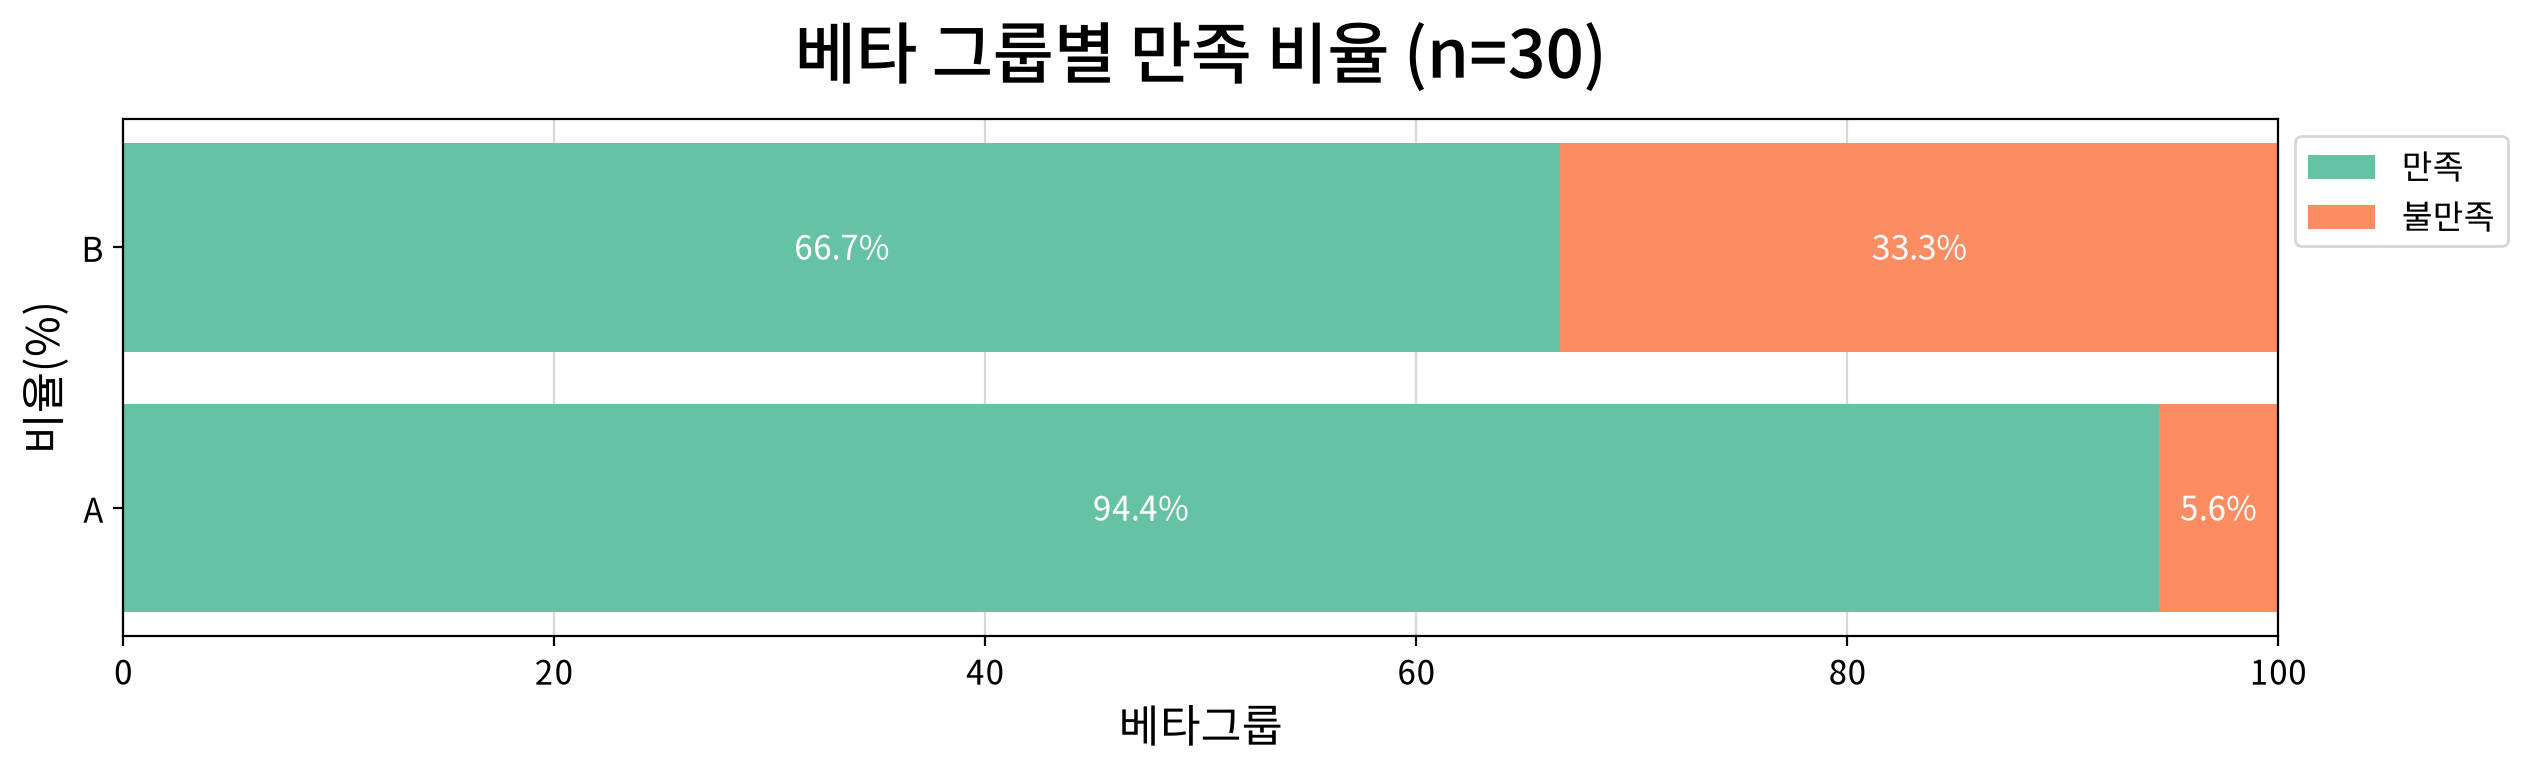

In [23]:
data = beta_df.copy()
data['인원'] = 1

my_plot.stackplot(data=data, x='베타그룹', y='인원', 
                  hue='베타만족', orient='h',
                  aggfunc='sum', ratio=True, palette='Set2',
                  title='베타 그룹별 만족 비율 (n=30)', 
                  xlabel='베타그룹', ylabel='비율(%)', height=400)

## #01.준비작업 

### 1. 라이브러리 참조 

In [24]:
from jussam import load_data
from helpers import *

### 2. 데이터셋 불러오기 

In [25]:
origin = load_data("movie_view")
origin.head()

📚 OTT 서비스 업체 무비뷰의 회원 500명을 대상으로 조사된 가상의 데이터 셋

    field         description
--  ------------  --------------------------------------
 0  회원ID        회원 식별자 (인덱스)
 1  가입요일      가입한 요일(월~일)
 2  성별          남성 / 여성
 3  프리미엄전환  프리미엄 요금제 전환 여부(전환/미전환)
 4  지역          서울 / 부산 / 대구
 5  선호장르      액션 / 로맨스 / 다큐 / 예능
 6  베타그룹      신규 UI 베타테스트 그룹(A/B)
 7  베타만족      베타테스트 만족 여부(만족/불만족)



,가입요일,성별,지역,선호장르,프리미엄전환,베타그룹,베타만족
회원ID,,,,,,,
M0001,토,여성,부산,다큐,미전환,NaN,NaN
M0002,토,남성,서울,예능,미전환,NaN,NaN
M0003,금,여성,대구,다큐,미전환,NaN,NaN
M0004,토,남성,서울,로맨스,미전환,NaN,NaN
M0005,일,남성,대구,다큐,미전환,NaN,NaN


## #01. 모듈화 기능 확인 

### 1. 적합도 검정 함수 

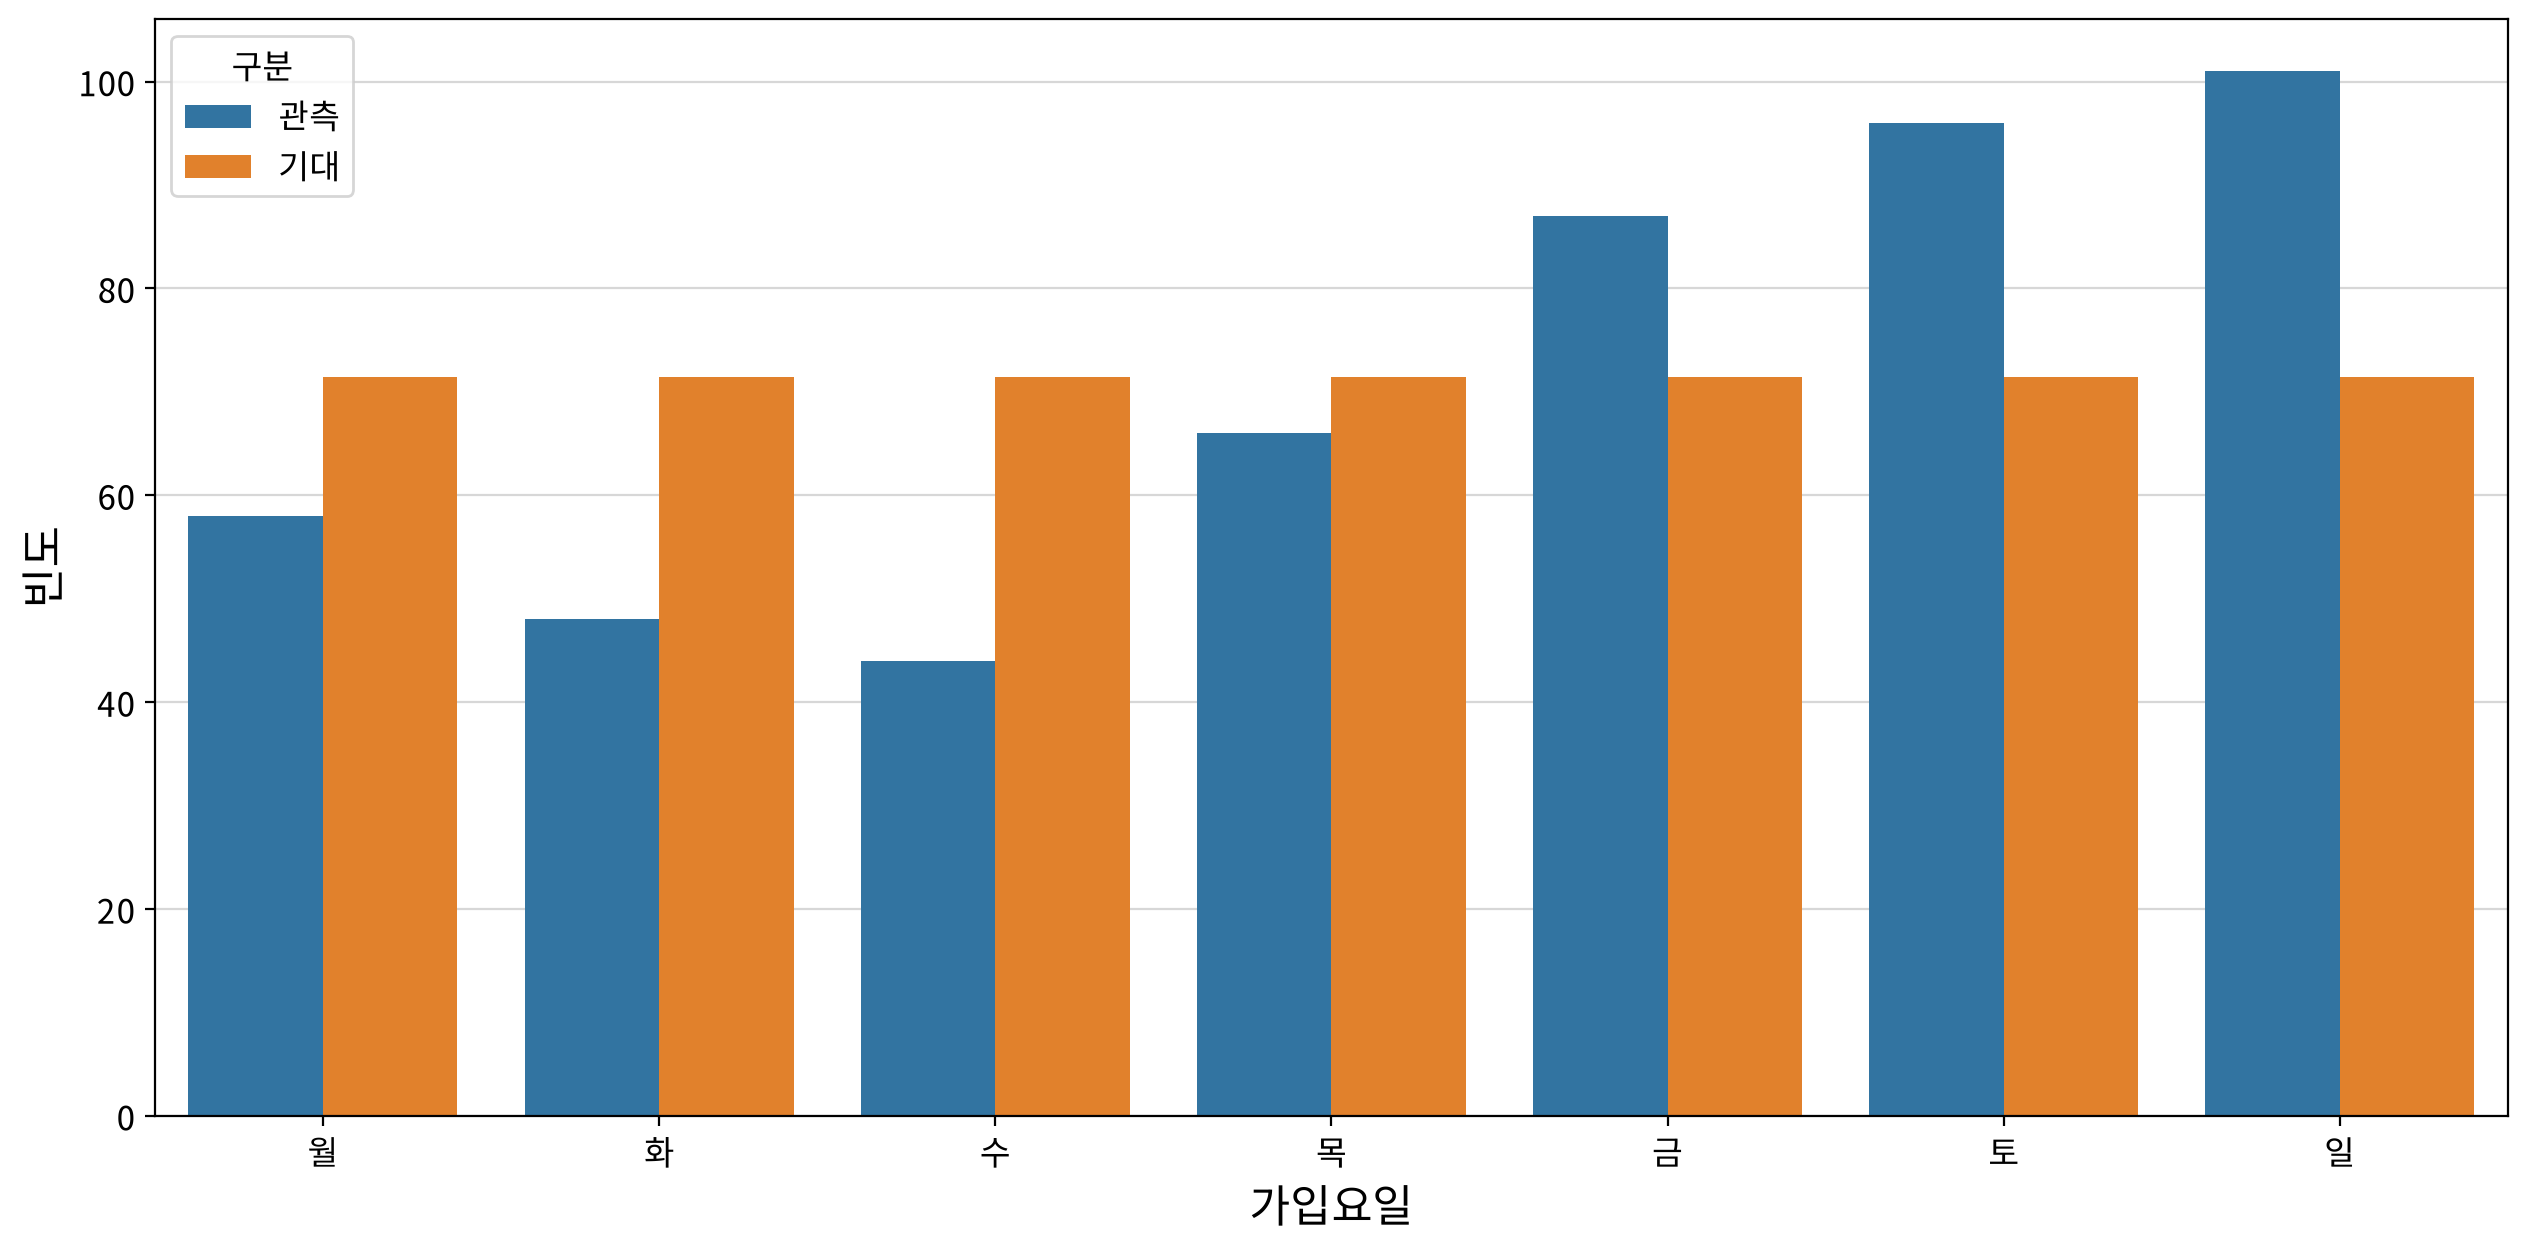

,chi2,dof,p-value,significant,effect(w),strength,min_expected,assumption
Chi-square goodness-of-fit,45.244,6,0.000,True,0.301,Moderate,71.430,True


In [26]:
my_stats.chi2_goodness_of_fit(origin, '가입요일', 
                              order=['월', '화', '수', '목', '금', '토', '일'])

### 2. 독립성 검정 함수 확인 

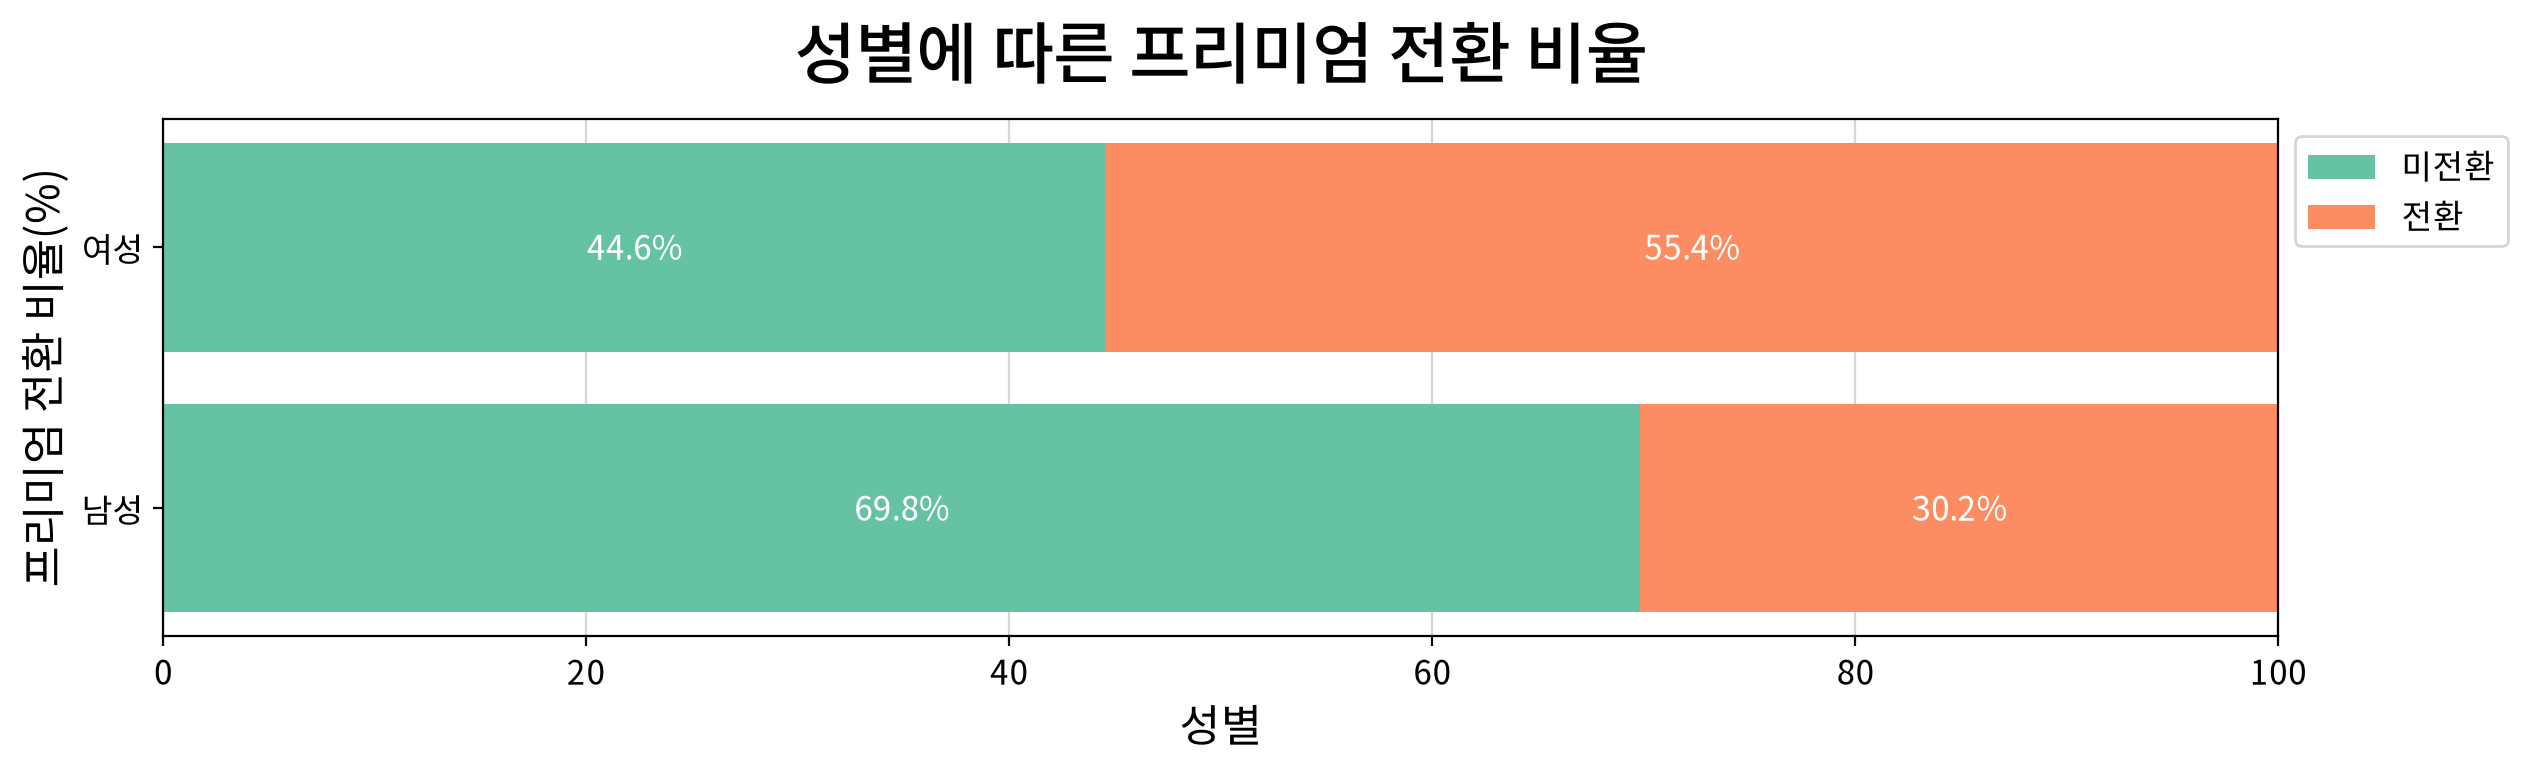

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
성별,프리미엄전환,Chi-square test of independence,31.453,1,0.000,True,0.177,Weak,104.540,True


In [27]:
my_stats.chi2_independence(origin, '성별', '프리미엄전환', 
                           orient='h', palette='Set2', 
                           title="성별에 따른 프리미엄 전환 비율", xlabel="성별", 
                           ylabel="프리미엄 전환 비율(%)", height=400)

### 3. 동질성 검정 함수 확인 

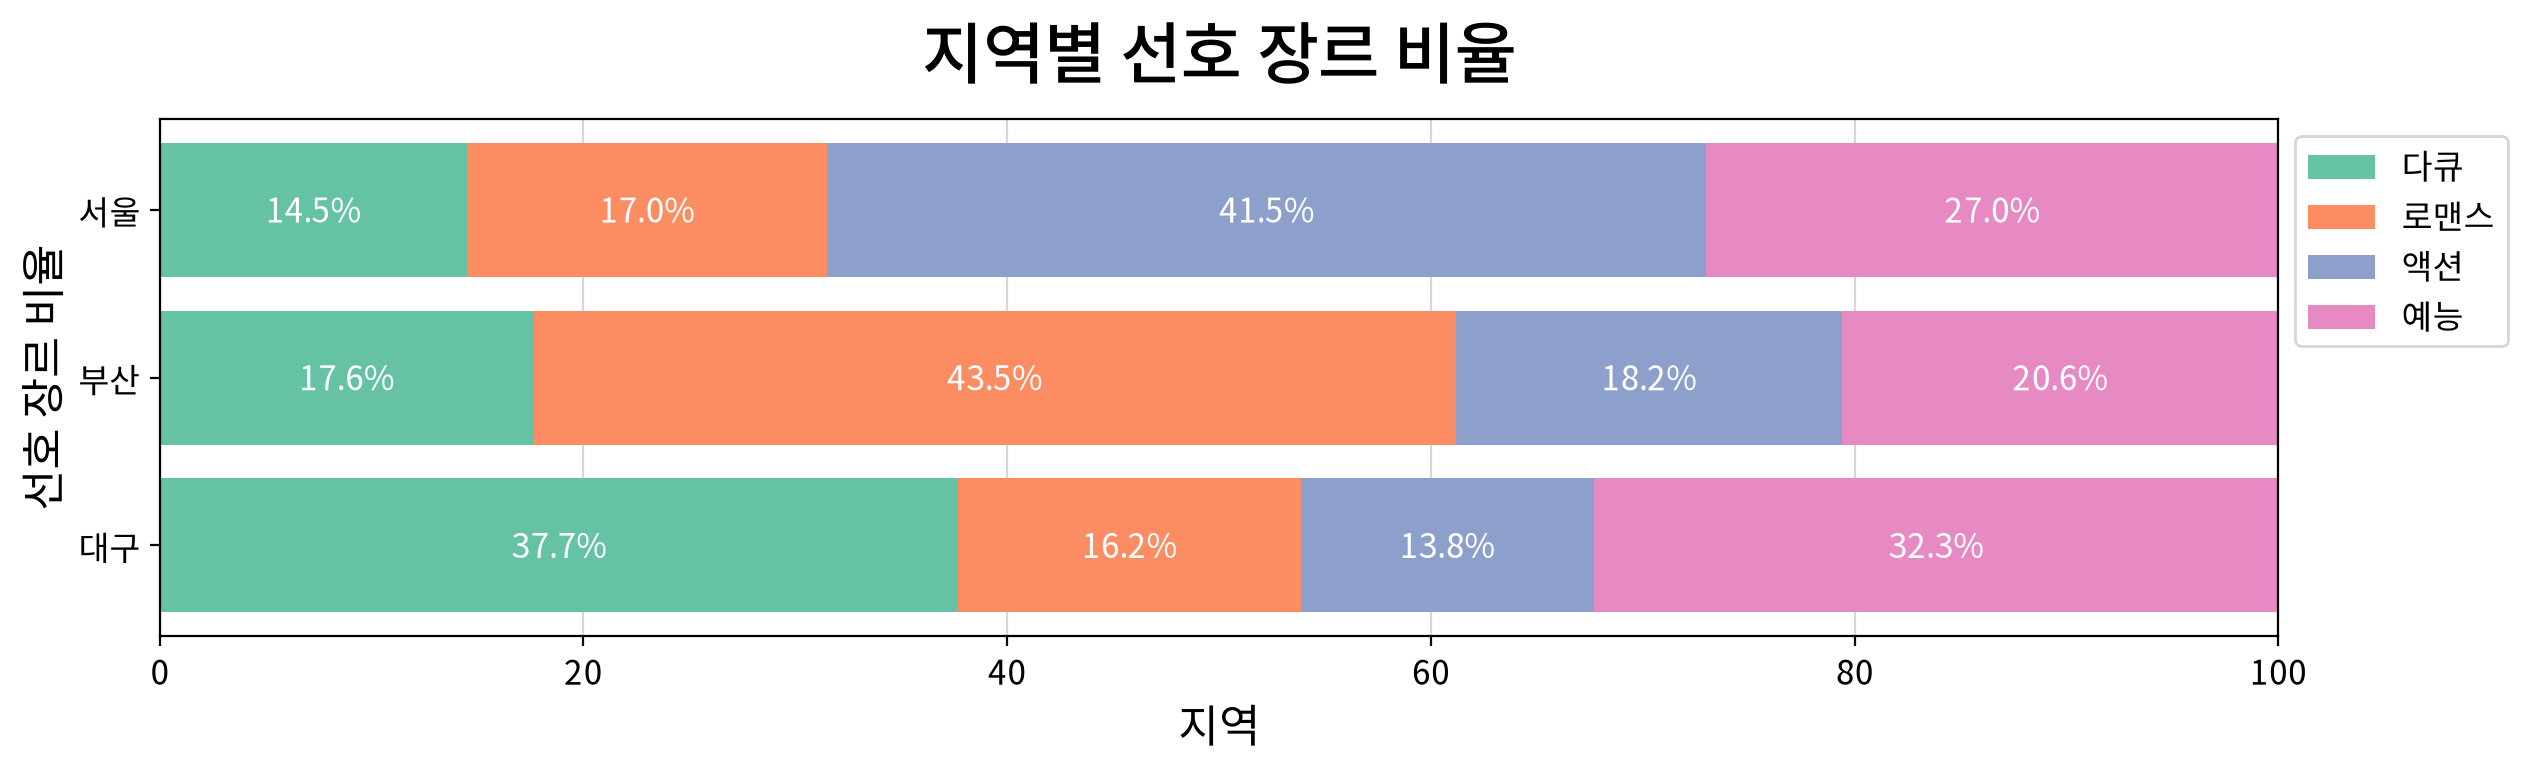

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
지역,선호장르,Chi-square test of homogenety,86.156,6,0.000,True,0.240,Weak,28.080,True


In [28]:
my_stats.chi2_homogeneity(origin, '지역', '선호장르', 
                          orient='h', palette='Set2', title="지역별 선호 장르 비율",
                          xlabel="지역", ylabel="선호 장르 비율", height=400)

## #01. 연습문제 

In [31]:
origin = load_data('wage')
origin.head()

📚 경제 및 노동 시장에 관련된 정보를 담고 있는 데이터셋(출처: ADsP 기출문제)

    field       description
--  ----------  ------------------
 0  year        년도
 1  age         나이
 2  maritl      결혼여부
 3  race        근로자의 인종
 4  education   교육수준
 5  region      지역
 6  jobclass    직군
 7  health      건상상태
 8  health_ins  건강보험 가입 여부
 9  logwage     임금(로그값)
10  wage        임금



,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318,75.043
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255,70.476
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875,130.982
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041,154.685
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318,75.043


In [30]:
df = origin.copy()
for c in ['maritl', 'race', 'education', 'region', 'jobclass', 'health', 'health_ins']:
    df[c] = df[c].str.replace(r'^\d+\.\s*', '', regex=True)

df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,Never Married,White,< HS Grad,Middle Atlantic,Industrial,<=Good,No,4.318,75.043
1,2004,24,Never Married,White,College Grad,Middle Atlantic,Information,>=Very Good,No,4.255,70.476
2,2003,45,Married,White,Some College,Middle Atlantic,Industrial,<=Good,Yes,4.875,130.982
3,2003,43,Married,Asian,College Grad,Middle Atlantic,Information,>=Very Good,Yes,5.041,154.685
4,2005,50,Divorced,White,HS Grad,Middle Atlantic,Information,<=Good,Yes,4.318,75.043
